In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'
TEST_YEAR = '2018'
NUTS2_EL = 'αττικης'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(8844, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL30,EL307,κυθηρων,2018,1,22.92536,36.22923,0.365836,0.118381,-0.299258,-0.118381,0.225004,0.089114,-0.157882,-0.089114,0.063362,0.051224,0.059956,0.051224,15.270645,12.314516,13.587143,15.691935,22.854667,8.366774,7.175806,7.766429,9.799677,12.676667,11.818710,9.745161,10.676786,12.745806,17.765667,3.15,17.25,5.362439,115.718359,150.551843,164.818729,814.180885,18.250000,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1
1,1,EL30,EL307,κυθηρων,2018,1,22.92536,36.31906,0.347835,0.340288,-0.285031,-0.340288,0.353388,0.371037,-0.284219,-0.371037,0.019758,0.038319,0.014281,0.038319,14.138387,12.109355,12.759286,16.326774,21.820000,9.819677,8.970645,8.125000,9.515806,12.658000,11.979032,10.540000,10.442143,12.921290,17.239000,4.03,17.15,4.296320,88.893759,118.679613,133.092486,503.337472,18.041667,18.583333,42.234848,742.066627,41.0,-3.0,44.0,10.000000,27.166667,27.166667,8.833333,2416.0,1087.0,4.0,146.980059,1616.0,57.0,57.0,703.0,31,30,50,11,10,1,6,6,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.0,5.117582,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1
2,2,EL30,EL307,κυθηρων,2018,1,22.92536,36.33703,0.460436,0.346079,-0.334576,-0.346079,0.340494,0.356525,-0.255628,-0.356525,0.029563,0.058059,0.018220,0.058059,13.459677,12.297097,12.128571,15.999032,20.210667,10.105484,8.939032,8.424286,10.559677,13.054000,11.782581,10.618065,10.276429,13.279355,16.632333,4.17,16.49,4.296320,88.893759,118.679613,133.092486,503.337472,18.041667,16.250000,39.634146,759.323363,41.0,0.0,41.0,10.333333,27.666667,27.666667,8.833333,2416.0,1087.0,4.0,146.980059,1616.0,57.0,57.0,703.0,11,10,10,1,1,7,1,1,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.0,1.487290,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1
3,3,EL30,EL307,κυθηρων,2018,1,22.94752,36.19329,0.591724,0.273221,-0.458678,-0.273221,0.299497,0.166521,-0.205863,-0.166521,0.064305,0.059351,0.047306,0.059351,13.678387,11.193871,13.521429,15.755806,24.292667,8.945484,7.207419,7.529286,9.644194,11.736667,11.311935,9.200645,10.525357,12.700000,18.014667,1.95,17.33,5.501343,119.626559,157.734871,170.533742,449.642070,18.291667,20.083333,43.659420,855.851074,43.0,-3.0,46.0,9.000000,28.833333,28.833333,7.833333,1786.0,506.0,1.0,92.885926,953.0,57.0,57.0,609.0,22,20,20,9,9,4,2,2,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.0,1.065844,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1
4,4,EL30,EL307,κυθηρων,2018,1,22.94752,36.21126,0.224960,-0.122628,-0.243195,0.122628,0.210937,-0.044113,-0.199345,0.044113,0.060486,0.056622,0.042711,0.056622,15.949355,12.063548,13.622857,17.017742,25.974667,7

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

737

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

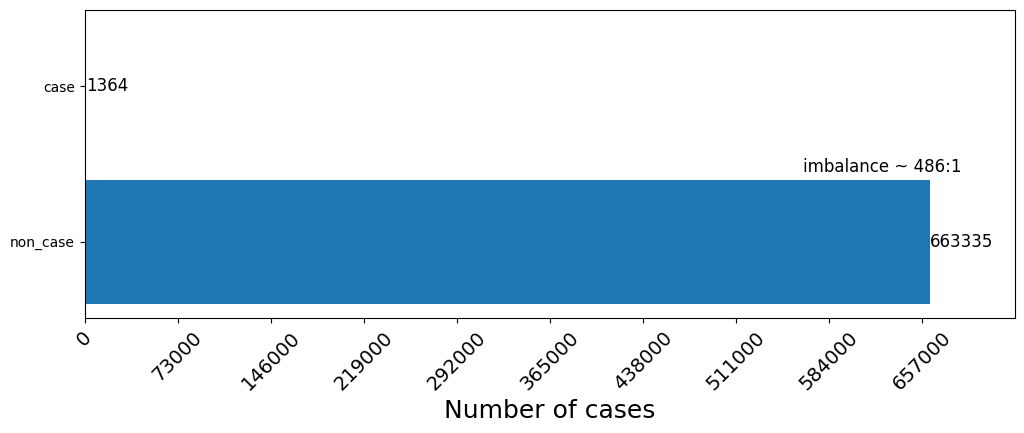

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

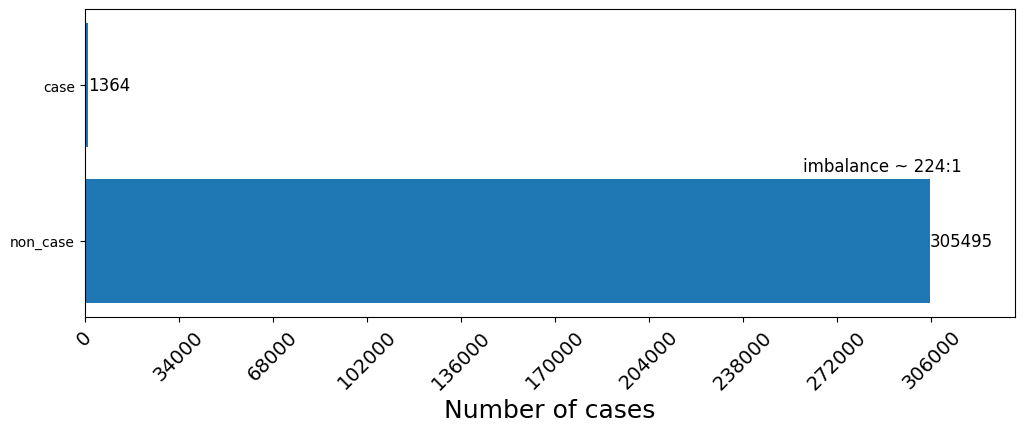

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

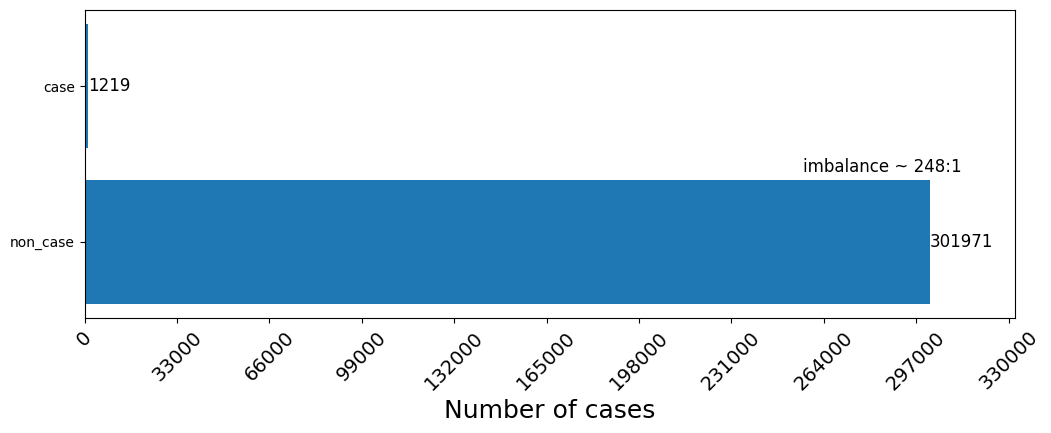

In [16]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

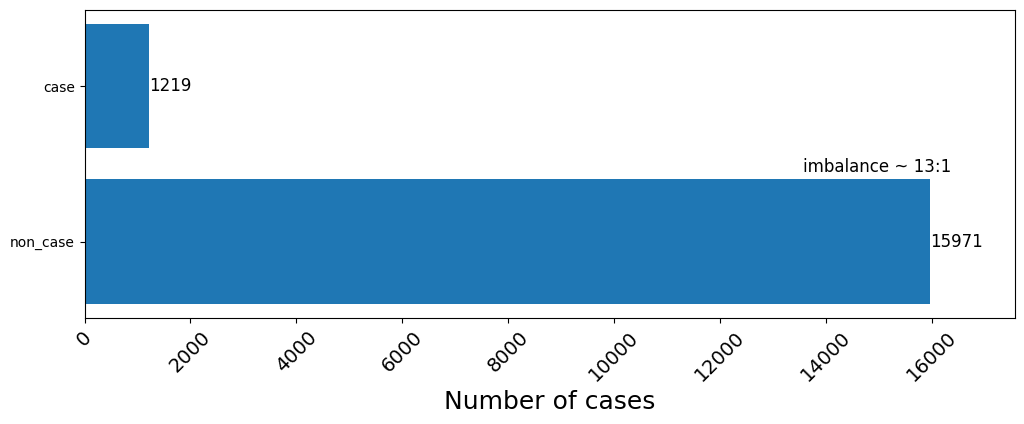

In [17]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [18]:
data_train.shape

(17072, 94)

In [19]:
data_train.cases.sum()

1219

In [20]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1354,262,1616,5.17%
1,2011,1315,100,1415,13.15%
2,2012,1329,157,1486,8.46%
3,2013,1374,85,1459,16.16%
4,2014,1289,15,1304,85.93%
5,2015,1380,0,1380,inf%
6,2016,1362,0,1362,inf%
7,2017,1290,42,1332,30.71%
8,2018,1136,151,1287,7.52%
9,2019,1359,218,1577,6.23%


In [21]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [22]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 13.10
Weight: 13.10


In [23]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [24]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL30,EL307,κυθηρων,2018,5,22.92536,36.22923,0.443291,0.090085,-0.423602,-0.090085,0.406997,0.083427,-0.390538,-0.083427,0.055358,0.047092,0.026341,0.047092,22.854667,12.314516,13.587143,15.691935,22.854667,12.676667,7.175806,7.766429,9.799677,12.676667,17.765667,9.745161,10.676786,12.745806,17.765667,9.13,31.85,1.763215,29.761134,32.919667,52.896458,1581.078625,18.250000,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1,0.500000,-0.866025
1,1,EL30,EL307,κυθηρων,2018,5,22.92536,36.31906,0.493176,0.161054,-0.403202,-0.161054,0.512624,0.168241,-0.429707,-0.168241,0.025080,0.017980,0.012152,0.017980,21.820000,12.109355,12.759286,16.326774,21.820000,12.658000,8.970645,8.125000,9.515806,12.658000,17.239000,10.540000,10.442143,12.921290,17.239000,8.93,30.33,2.051730,25.002768,27.782460,61.551898,1118.493169,18.041667,18.583333,42.234848,742.066627,41.0,-3.0,44.0,10.000000,27.166667,27.166667,8.833333,2416.0,1087.0,4.0,146.980059,1616.0,57.0,57.0,703.0,31,30,50,11,10,1,6,6,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.0,5.117582,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1,0.500000,-0.866025
2,2,EL30,EL307,κυθηρων,2018,5,22.92536,36.33703,0.544007,0.203285,-0.446943,-0.203285,0.544270,0.251370,-0.447623,-0.251370,0.027438,0.045818,0.012479,0.045818,20.210667,12.297097,12.128571,15.999032,20.210667,13.054000,8.939032,8.424286,10.559677,13.054000,16.632333,10.618065,10.276429,13.279355,16.632333,9.63,28.73,2.051730,25.002768,27.782460,61.551898,1118.493169,18.041667,16.250000,39.634146,759.323363,41.0,0.0,41.0,10.333333,27.666667,27.666667,8.833333,2416.0,1087.0,4.0,146.980059,1616.0,57.0,57.0,703.0,11,10,10,1,1,7,1,1,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.0,1.487290,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1,0.500000,-0.866025
3,3,EL30,EL307,κυθηρων,2018,5,22.94752,36.19329,0.587948,0.250445,-0.492995,-0.250445,0.519675,0.187287,-0.450024,-0.187287,0.061828,0.058270,0.036924,0.058270,24.292667,11.193871,13.521429,15.755806,24.292667,11.736667,7.207419,7.529286,9.644194,11.736667,18.014667,9.200645,10.525357,12.700000,18.014667,8.19,32.73,0.734465,4.691186,8.364401,22.033940,1171.822376,18.291667,20.083333,43.659420,855.851074,43.0,-3.0,46.0,9.000000,28.833333,28.833333,7.833333,1786.0,506.0,1.0,92.885926,953.0,57.0,57.0,609.0,22,20,20,9,9,4,2,2,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.0,1.065844,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9400.12,20505.0,19753.0,2,1,1,0.500000,-0.866025
4,4,EL30,EL307,κυθηρων,2018,5,22.94752,36.21126,0.389864,0.069799,-0.404412,-0.069799,0.379844,0.072526,-0.383017,-0.072

### Results 2018 ###

In [25]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
332,332,EL30,EL303,αθηναιων,2018,5,23.70093,37.98996,0.047761
382,382,EL30,EL303,φιλαδελφειας χαλκηδονος,2018,5,23.74525,38.04386,0.041740
409,409,EL30,EL301,μεταμορφωσεως,2018,5,23.76741,38.06183,0.037254
329,329,EL30,EL304,παλαιου φαληρου,2018,5,23.70093,37.93606,0.037051
381,381,EL30,EL303,αθηναιων,2018,5,23.74525,38.02590,0.034552


In [32]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
380,380,EL30,EL303,αθηναιων,2018,6,23.74525,38.00793,0.347647
145,145,EL30,EL306,μεγαρεων,2018,6,23.34639,37.98996,0.306717
329,329,EL30,EL304,παλαιου φαληρου,2018,6,23.70093,37.93606,0.243461
489,489,EL30,EL301,χαλανδριου,2018,6,23.83388,38.02590,0.176385
488,488,EL30,EL301,αγιας παρασκευης,2018,6,23.83388,38.00793,0.175622


In [33]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
397,397,EL30,EL305,ωρωπου,2018,7,23.74525,38.31336,0.672393
451,451,EL30,EL305,ωρωπου,2018,7,23.78956,38.31336,0.636582
380,380,EL30,EL303,αθηναιων,2018,7,23.74525,38.00793,0.587856
145,145,EL30,EL306,μεγαρεων,2018,7,23.34639,37.98996,0.572821
423,423,EL30,EL305,ωρωπου,2018,7,23.76741,38.31336,0.572712


In [34]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
329,329,EL30,EL304,παλαιου φαληρου,2018,8,23.70093,37.93606,0.663230
397,397,EL30,EL305,ωρωπου,2018,8,23.74525,38.31336,0.631380
451,451,EL30,EL305,ωρωπου,2018,8,23.78956,38.31336,0.578653
145,145,EL30,EL306,μεγαρεων,2018,8,23.34639,37.98996,0.571346
350,350,EL30,EL305,ωρωπου,2018,8,23.70093,38.31336,0.545519


In [35]:
results_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
145,145,EL30,EL306,μεγαρεων,2018,9,23.34639,37.98996,0.685251
380,380,EL30,EL303,αθηναιων,2018,9,23.74525,38.00793,0.607731
397,397,EL30,EL305,ωρωπου,2018,9,23.74525,38.31336,0.585030
373,373,EL30,EL304,γλυφαδας,2018,9,23.74525,37.88216,0.570295
350,350,EL30,EL305,ωρωπου,2018,9,23.70093,38.31336,0.564753


In [36]:
results_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
145,145,EL30,EL306,μεγαρεων,2018,10,23.34639,37.98996,0.562052
380,380,EL30,EL303,αθηναιων,2018,10,23.74525,38.00793,0.501561
165,165,EL30,EL306,μεγαρεων,2018,10,23.36854,37.98996,0.410640
437,437,EL30,EL301,λυκοβρυσης πευκης,2018,10,23.78956,38.06183,0.352741
489,489,EL30,EL301,χαλανδριου,2018,10,23.83388,38.02590,0.335875


In [37]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [38]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [39]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((22.93644 36.22024, 22.91428 36.22024..."
1,1,"POLYGON ((22.93644 36.31008, 22.91428 36.31008..."
2,2,"POLYGON ((22.93644 36.32804, 22.91428 36.32804..."
3,3,"POLYGON ((22.95860 36.18431, 22.93644 36.18431..."
4,4,"POLYGON ((22.95860 36.20228, 22.93644 36.20228..."


In [40]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL30,Aττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [41]:
greece_lau1.head()

,NAME,geometry
0,Ελευσίνας,"POLYGON ((23.50387 38.13648, 23.50497 38.13616..."
1,Ιλίου,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
2,Ύδρας,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
3,Αίγινας,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
4,Αγίας Βαρβάρας,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."


In [42]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,MARATHONA RESERVOIR,2982333.8,11410.567,"POLYGON ((23.87974 38.17811, 23.88232 38.17924...",0


In [43]:
results_may = pd.merge(results_may, region_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')
results_may['x'] = results_may['x'].round(4)
results_may['y'] = results_may['y'].round(4)
results_may.rename(columns={'score': 'risk_score'}, inplace=True)
results_may['risk_score'] = results_may['risk_score'].round(6)

results_jun = pd.merge(results_jun, region_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')
results_jun['x'] = results_jun['x'].round(4)
results_jun['y'] = results_jun['y'].round(4)
results_jun.rename(columns={'score': 'risk_score'}, inplace=True)
results_jun['risk_score'] = results_jun['risk_score'].round(6)

results_jul = pd.merge(results_jul, region_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')
results_jul['x'] = results_jul['x'].round(4)
results_jul['y'] = results_jul['y'].round(4)
results_jul.rename(columns={'score': 'risk_score'}, inplace=True)
results_jul['risk_score'] = results_jul['risk_score'].round(6)

results_aug = pd.merge(results_aug, region_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')
results_aug['x'] = results_aug['x'].round(4)
results_aug['y'] = results_aug['y'].round(4)
results_aug.rename(columns={'score': 'risk_score'}, inplace=True)
results_aug['risk_score'] = results_aug['risk_score'].round(6)

results_sep = pd.merge(results_sep, region_grid, on='cell_number', how='left')
results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')
results_sep['x'] = results_sep['x'].round(4)
results_sep['y'] = results_sep['y'].round(4)
results_sep.rename(columns={'score': 'risk_score'}, inplace=True)
results_sep['risk_score'] = results_sep['risk_score'].round(6)

results_oct = pd.merge(results_oct, region_grid, on='cell_number', how='left')
results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')
results_oct['x'] = results_oct['x'].round(4)
results_oct['y'] = results_oct['y'].round(4)
results_oct.rename(columns={'score': 'risk_score'}, inplace=True)
results_oct['risk_score'] = results_oct['risk_score'].round(6)

In [44]:
type(results_may)

geopandas.geodataframe.GeoDataFrame

In [45]:
# results_may.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_aug.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_sep.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [46]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

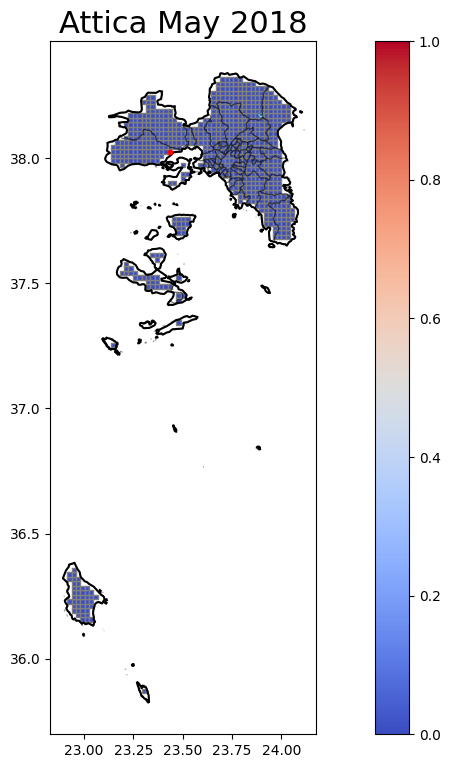

In [47]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 5)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

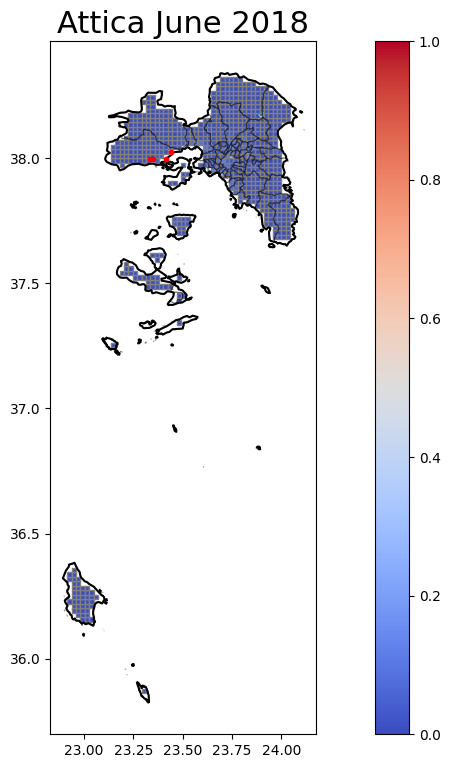

In [48]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 6)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

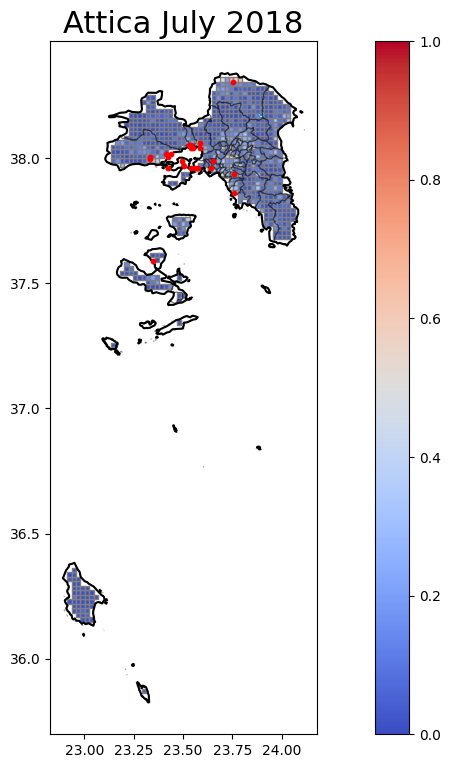

In [49]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 7)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

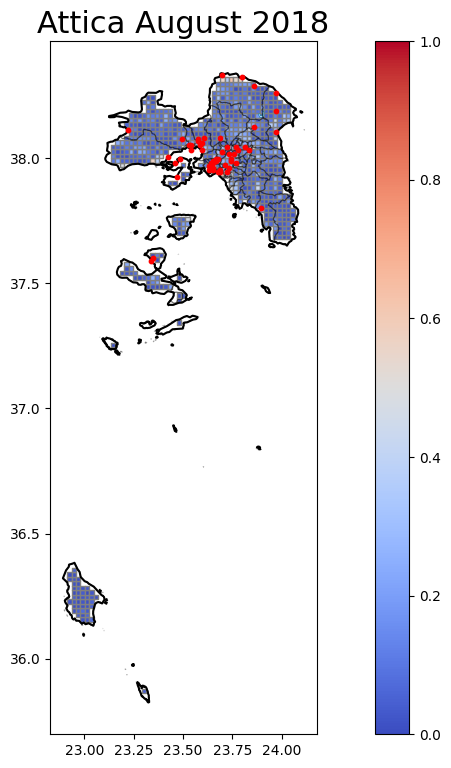

In [50]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

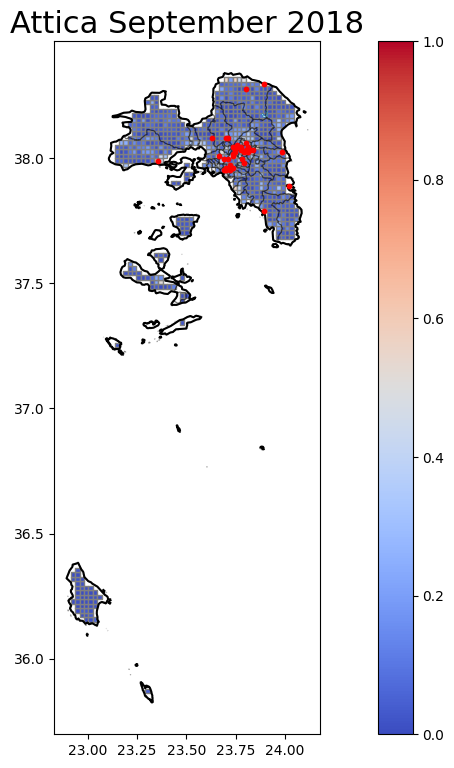

In [51]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 9)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

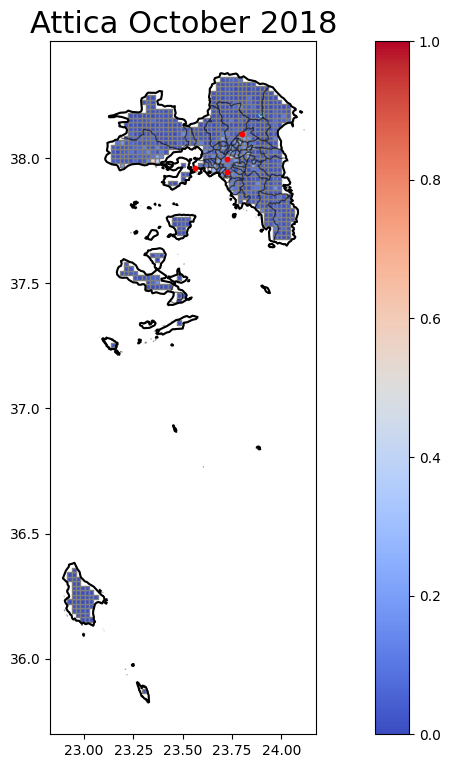

In [52]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 10)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [54]:
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_nuts3_gdf, wnv_cases_grid, 
                                 index_col='cell_number', color_col='risk_score', hover_name='lau1', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8, line_color_f4='#3b3b3b', fig_title = '[EL30]Attica - August 2018',
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=650, fig_width=1000, size_f5=6.5)

fig.show()
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")